In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_moons, make_circles

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

---
# 1) NumPy Foundations & Vectorization

NumPy's strength lies in **vectorized operations** — applying element-wise or matrix operations
without explicit Python loops. This section establishes the computational primitives that
underpin every neural network implementation.

---

## 1.1 Broadcasting Rules

Broadcasting lets NumPy perform arithmetic on arrays of different shapes by
**virtually expanding** the smaller array. The rules are:

1. If arrays differ in ndim, prepend 1s to the shape of the smaller array.
2. Arrays with size 1 along a dimension act as if they have the size of the larger array along that dimension.
3. If sizes disagree and neither is 1 → error.

**Sample:**
```
A: (3, 4)  +  B: (1, 4)  →  result: (3, 4)
A: (3, 1)  +  B: (1, 4)  →  result: (3, 4)
A: (3, 4)  +  B: (4,)    →  result: (3, 4)   # B becomes (1, 4) first
```

In [ ]:
# Demonstrate broadcasting with explicit shape tracking

A = np.random.randn(3, 4)
b_row = np.random.randn(1, 4)
b_col = np.random.randn(3, 1)
b_vec = np.random.randn(4)

# (3, 4) + (1, 4) → (3, 4)  — row vector broadcast across rows
result_row = A + b_row
print(f"A{A.shape} + b_row{b_row.shape} = {result_row.shape}")

# (3, 4) + (3, 1) → (3, 4)  — column vector broadcast across columns
result_col = A + b_col
print(f"A{A.shape} + b_col{b_col.shape} = {result_col.shape}")

# (3, 4) + (4,) → (3, 4)  — 1D vector promotes to (1, 4) then broadcasts
result_vec = A + b_vec
print(f"A{A.shape} + b_vec{b_vec.shape} = {result_vec.shape}")

# Outer product via broadcasting: column * row
# (3, 1) * (1, 4) → (3, 4)
outer = b_col * b_row
print(f"\nOuter product: {b_col.shape} * {b_row.shape} = {outer.shape}")
print(outer)

A(3, 4) + b_row(1, 4) = (3, 4)
A(3, 4) + b_col(3, 1) = (3, 4)
A(3, 4) + b_vec(4,) = (3, 4)

Outer product: (3, 1) * (1, 4) = (3, 4)
[[-0.24506692  1.93782977  1.74705046  0.56950231]
 [ 0.076036   -0.60124321 -0.54205083 -0.17669736]
 [-0.21970757  1.73730453  1.56626692  0.51057061]]


## 1.2 Vectorization vs Loops

A Python `for`-loop over array elements invokes the interpreter per iteration.
Vectorized NumPy delegates the loop to compiled C code — often **100–1000×** faster.

We benchmark: dot product of two vectors with $n = 10^6$ elements.

In [ ]:
num_samples = 1_000_000
x = np.random.randn(num_samples)
y = np.random.randn(num_samples)

# Explicit Python loop
start = time.perf_counter()
dot_loop = 0.0
for i in range(num_samples):
    dot_loop += x[i] * y[i]
time_loop = time.perf_counter() - start

# Vectorized NumPy dot
start = time.perf_counter()
# (num_samples,) · (num_samples,) → scalar
dot_vec = np.dot(x, y)
time_vec = time.perf_counter() - start

print(f"Loop:       {time_loop:.4f}s  result={dot_loop:.6f}")
print(f"Vectorized: {time_vec:.6f}s  result={dot_vec:.6f}")
print(f"Speedup:    {time_loop / time_vec:.0f}x")

Loop:       1.4134s  result=895.455034
Vectorized: 0.005041s  result=895.455034
Speedup:    280x


In [ ]:
# Matrix-vector product: loop vs vectorized
num_samples, embed_dim = 500, 300
W = np.random.randn(num_samples, embed_dim)
v = np.random.randn(embed_dim)

# Loop version
start = time.perf_counter()
result_loop = np.zeros(num_samples)
for i in range(num_samples):
    for j in range(embed_dim):
        result_loop[i] += W[i, j] * v[j]
time_loop = time.perf_counter() - start

# Vectorized
start = time.perf_counter()
# (num_samples, embed_dim) @ (embed_dim,) → (num_samples,)
result_vec = W @ v
time_vec = time.perf_counter() - start

print(f"Loop:       {time_loop:.4f}s")
print(f"Vectorized: {time_vec:.6f}s")
print(f"Speedup:    {time_loop / time_vec:.0f}x")
print(f"Max diff:   {np.max(np.abs(result_loop - result_vec)):.2e}")

Loop:       0.3461s
Vectorized: 0.000474s
Speedup:    729x
Max diff:   6.39e-14


## 1.3 Sigmoid & Softmax

These are the two most important activation/output functions in classification:

**Sigmoid** (binary classification):
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Softmax** (multi-class classification):
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

Both must be implemented in a **numerically stable** way to avoid overflow.

In [ ]:
def sigmoid(z):
    """Numerically stable sigmoid: clips input to avoid overflow."""
    z_clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_clipped))


def softmax(z):
    """Numerically stable softmax along axis 0 (classes axis).

    Subtracting the max prevents exp overflow while preserving the output
    distribution (shift-invariance of softmax).
    """
    # (num_classes, batch_num) → (num_classes, batch_num)
    z_shifted = z - np.max(z, axis=0, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)


# Verify sigmoid
z_test = np.array([-1000, -1, 0, 1, 1000])
print("Sigmoid:", sigmoid(z_test))

# Verify softmax on a (num_classes=3, batch_num=2) matrix
z_mat = np.array([[2.0, 1.0], [1.0, 2.0], [0.1, 0.1]])
sm = softmax(z_mat)
print(f"\nSoftmax input shape: {z_mat.shape}")
print(f"Softmax output:\n{sm}")
print(f"Column sums (should be 1.0): {sm.sum(axis=0)}")

Sigmoid: [7.12457641e-218 2.68941421e-001 5.00000000e-001 7.31058579e-001
 1.00000000e+000]

Softmax input shape: (3, 2)
Softmax output:
[[0.65900114 0.24243297]
 [0.24243297 0.65900114]
 [0.09856589 0.09856589]]
Column sums (should be 1.0): [1. 1.]


## 1.4 L1 and L2 Distance

Distance metrics are fundamental to classification, clustering, and regularization.

$$\|x\|_1 = \sum_i |x_i| \qquad \text{(L1 / Manhattan)}$$
$$\|x\|_2 = \sqrt{\sum_i x_i^2} \qquad \text{(L2 / Euclidean)}$$

**Pairwise distance** between $N$ points in $\mathbb{R}^d$ can be computed fully vectorized.

In [ ]:
def l1_distance(x, y):
    """Element-wise L1 distance."""
    # (embed_dim,) → scalar
    return np.sum(np.abs(x - y))


def l2_distance(x, y):
    """Element-wise L2 distance."""
    # (embed_dim,) → scalar
    return np.sqrt(np.sum((x - y) ** 2))


def pairwise_l2(X):
    """Fully vectorized pairwise L2 distance matrix.

    Uses the identity: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a.b
    """
    # (num_samples, embed_dim) → (num_samples, num_samples)
    sq_norms = np.sum(X ** 2, axis=1, keepdims=True)
    dist_sq = sq_norms + sq_norms.T - 2.0 * X @ X.T
    return np.sqrt(np.maximum(dist_sq, 0.0))


x = np.array([1.0, 3.0, -2.0])
y = np.array([0.0, 1.0, 4.0])
print(f"L1 distance: {l1_distance(x, y)}")
print(f"L2 distance: {l2_distance(x, y):.4f}")

# Pairwise distances for 5 points in R^3
X_pts = np.random.randn(5, 3)
D = pairwise_l2(X_pts)
print(f"\nPairwise distance matrix shape: {D.shape}")
print(f"Symmetric: {np.allclose(D, D.T)}")
print(f"Zero diagonal: {np.allclose(np.diag(D), 0)}")
print(D.round(3))

L1 distance: 9.0
L2 distance: 6.4031

Pairwise distance matrix shape: (5, 5)
Symmetric: True
Zero diagonal: True
[[0.    2.636 3.699 2.986 0.859]
 [2.636 0.    1.78  1.502 1.792]
 [3.699 1.78  0.    2.201 2.917]
 [2.986 1.502 2.201 0.    2.352]
 [0.859 1.792 2.917 2.352 0.   ]]


---
# 2) Logistic Regression

Logistic regression is the simplest neural network: **a single neuron with a sigmoid
activation**. Building it from scratch establishes the forward-backward pattern
that scales to arbitrary depth.

---

## 2.1 Binary classification

X shape: (2, 400)  (input_dim, batch_num)
Y shape: (1, 400)  (1, batch_num)
Class balance: 0.50


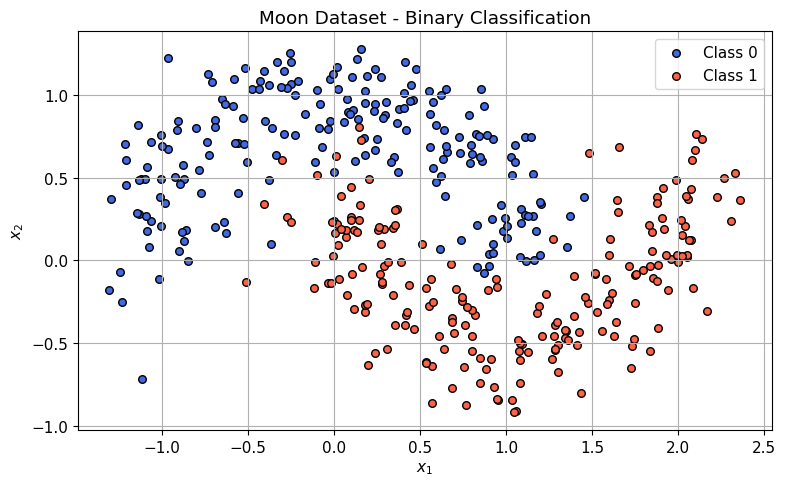

In [ ]:
# Generate the moon dataset
num_samples = 400
X_moons, y_moons = make_moons(n_samples=num_samples, noise=0.20, random_state=42)

# Transpose to column convention: each column is one sample
# (num_samples, 2) → (2, num_samples)
X = X_moons.T
# (num_samples,) → (1, num_samples)
Y = y_moons.reshape(1, -1)

input_dim, batch_num = X.shape
print(f"X shape: {X.shape}  (input_dim, batch_num)")
print(f"Y shape: {Y.shape}  (1, batch_num)")
print(f"Class balance: {Y.mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X[0, Y[0] == 0], X[1, Y[0] == 0], c="royalblue", label="Class 0", edgecolors="k", s=30)
ax.scatter(X[0, Y[0] == 1], X[1, Y[0] == 1], c="tomato", label="Class 1", edgecolors="k", s=30)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Moon Dataset - Binary Classification")
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 The Sigmoid Function
The sigmoid maps any real number to $(0, 1)$, interpreting the output as $P(y=1 | \mathbf{x})$.

Key properties:
- $\sigma(0) = 0.5$
- $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — the derivative is expressible in terms of itself
- Saturates for $|z| \gg 0$, which causes **vanishing gradients** in deep networks

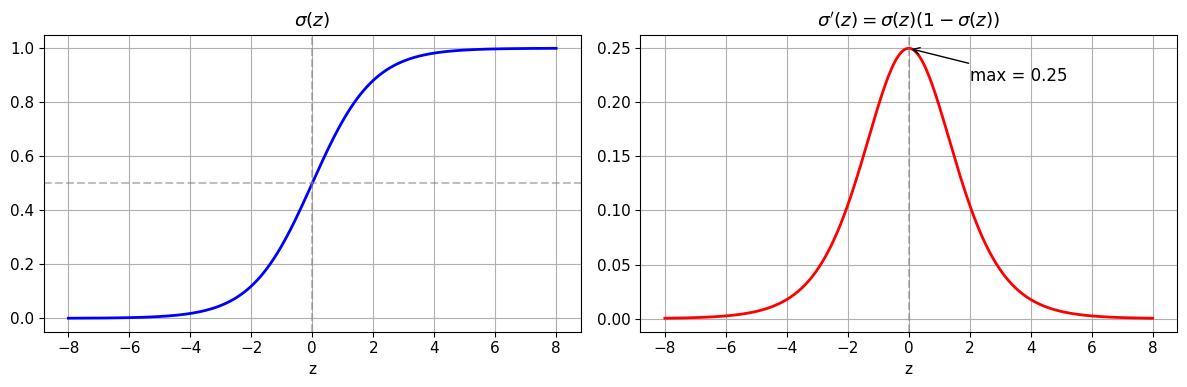

In [ ]:
# Visualize sigmoid and its derivative
z = np.linspace(-8, 8, 300)

# (300,) → (300,)
sig = sigmoid(z)
sig_grad = sig * (1 - sig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(z, sig, "b-", linewidth=2)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title(r"$\sigma(z)$")
axes[0].set_xlabel("z")

axes[1].plot(z, sig_grad, "r-", linewidth=2)
axes[1].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title(r"$\sigma'(z) = \sigma(z)(1-\sigma(z))$")
axes[1].set_xlabel("z")
axes[1].annotate(f"max = {sig_grad.max():.2f}", xy=(0, 0.25), fontsize=12,
                 arrowprops=dict(arrowstyle="->"), xytext=(2, 0.22))

plt.tight_layout()
plt.show()

## 2.3 Binary Cross-Entropy Loss
We need a loss function that:
1. Is **differentiable** (for gradient descent)
2. **Penalizes confident wrong predictions** heavily
3. Has a **probabilistic interpretation** (negative log-likelihood of Bernoulli)

**Derivation from Maximum Likelihood:**

For $y \in \{0, 1\}$ and predicted probability $\hat{y} = P(y=1|\mathbf{x})$:

$$P(y | \mathbf{x}) = \hat{y}^{y} (1 - \hat{y})^{1-y}$$

Taking the negative log:

$$L(y, \hat{y}) = -\left[ y \log \hat{y} + (1-y) \log(1-\hat{y}) \right]$$

Over $m$ samples:

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

In [ ]:
def compute_cost(Y, A):
    """Binary cross-entropy cost, averaged over samples.

    Clips predictions to avoid log(0).
    """
    # (1, batch_num), (1, batch_num) → scalar
    batch_num = Y.shape[1]
    A_clipped = np.clip(A, 1e-12, 1 - 1e-12)
    cost = -np.sum(Y * np.log(A_clipped) + (1 - Y) * np.log(1 - A_clipped)) / batch_num
    return float(cost)


# Sanity check: perfect prediction → low cost, bad prediction → high cost
print(f"Perfect:  cost = {compute_cost(np.array([[1,0,1]]), np.array([[0.99, 0.01, 0.99]])):.4f}")
print(f"Random:   cost = {compute_cost(np.array([[1,0,1]]), np.array([[0.5, 0.5, 0.5]])):.4f}")
print(f"Terrible: cost = {compute_cost(np.array([[1,0,1]]), np.array([[0.01, 0.99, 0.01]])):.4f}")

Perfect:  cost = 0.0101
Random:   cost = 0.6931
Terrible: cost = 4.6052


## 2.4 Gradient Computation (backward pass — manual derivation)

We need $\frac{\partial J}{\partial \mathbf{w}}$ and $\frac{\partial J}{\partial b}$.

**Forward pass:**
$$z = \mathbf{w}^T \mathbf{x} + b, \qquad \hat{y} = \sigma(z)$$

**Backward pass** (chain rule):

$$\frac{\partial L}{\partial z} = \hat{y} - y$$

This elegantly simple form comes from:
$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \hat{y}(1-\hat{y}) = \hat{y} - y$$

Then:
$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X} (\hat{\mathbf{y}} - \mathbf{y})^T$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

In [ ]:
def logistic_forward(X, w, b):
    """Logistic regression forward pass."""
    # z: (input_dim, batch_num).T @ (input_dim, 1) + scalar → (1, batch_num)
    z = w.T @ X + b
    A = sigmoid(z)
    return A, z


def logistic_backward(X, Y, A):
    """Logistic regression backward pass: returns gradients for w and b."""
    batch_num = X.shape[1]

    # (1, batch_num)
    dz = A - Y

    # (input_dim, batch_num) @ (batch_num, 1) → (input_dim, 1)
    dw = (1 / batch_num) * (X @ dz.T)

    # scalar
    db = (1 / batch_num) * np.sum(dz)

    return dw, db

## 2.5 Gradient Descent Update Rule

The update is straightforward:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \frac{\partial J}{\partial \mathbf{w}}$$
$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

where $\alpha$ is the learning rate. Choosing $\alpha$ too large causes divergence;
too small causes slow convergence. We use $\alpha = 1.0$ here since
the problem is small-scale.

## 2.6 Full Training Loop

In [ ]:
def train_logistic_regression(X, Y, learning_rate=1.0, num_iterations=2000, print_every=200):
    """Train logistic regression with gradient descent."""
    input_dim, batch_num = X.shape

    # Initialize weights to zeros (common for logistic regression)
    # (input_dim, 1)
    w = np.zeros((input_dim, 1))
    b = 0.0

    costs = []

    for i in range(num_iterations):
        # Forward pass
        A, z = logistic_forward(X, w, b)

        # Compute cost
        cost = compute_cost(Y, A)
        costs.append(cost)

        # Backward pass
        dw, db = logistic_backward(X, Y, A)

        # Update parameters
        w -= learning_rate * dw
        b -= learning_rate * db

        if i % print_every == 0:
            predictions = (A > 0.5).astype(float)
            accuracy = np.mean(predictions == Y) * 100
            print(f"Iter {i:4d} | Cost: {cost:.4f} | Accuracy: {accuracy:.1f}%")

    return w, b, costs


w_lr, b_lr, costs_lr = train_logistic_regression(X, Y)

Iter    0 | Cost: 0.6931 | Accuracy: 50.0%
Iter  200 | Cost: 0.3065 | Accuracy: 83.8%
Iter  400 | Cost: 0.3060 | Accuracy: 84.0%
Iter  600 | Cost: 0.3060 | Accuracy: 84.2%
Iter  800 | Cost: 0.3060 | Accuracy: 84.2%
Iter 1000 | Cost: 0.3060 | Accuracy: 84.2%
Iter 1200 | Cost: 0.3060 | Accuracy: 84.2%
Iter 1400 | Cost: 0.3060 | Accuracy: 84.2%
Iter 1600 | Cost: 0.3060 | Accuracy: 84.2%
Iter 1800 | Cost: 0.3060 | Accuracy: 84.2%


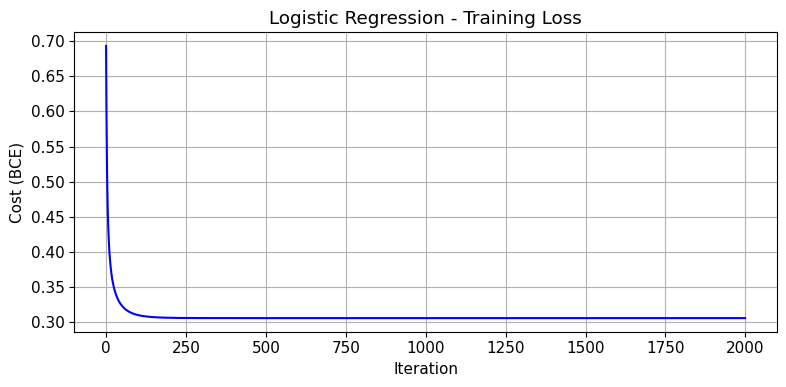

In [ ]:
# Plot the training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs_lr, "b-", linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost (BCE)")
ax.set_title("Logistic Regression - Training Loss")
plt.tight_layout()
plt.show()

## 2.7 Decision Boundary Visualization

The decision boundary is the set of points where $\hat{y} = 0.5$, i.e., $\mathbf{w}^T\mathbf{x} + b = 0$.

For logistic regression this is always a **hyperplane** (a line in 2D). We can see that
it cannot capture the curvature of the moon dataset — motivating neural networks.

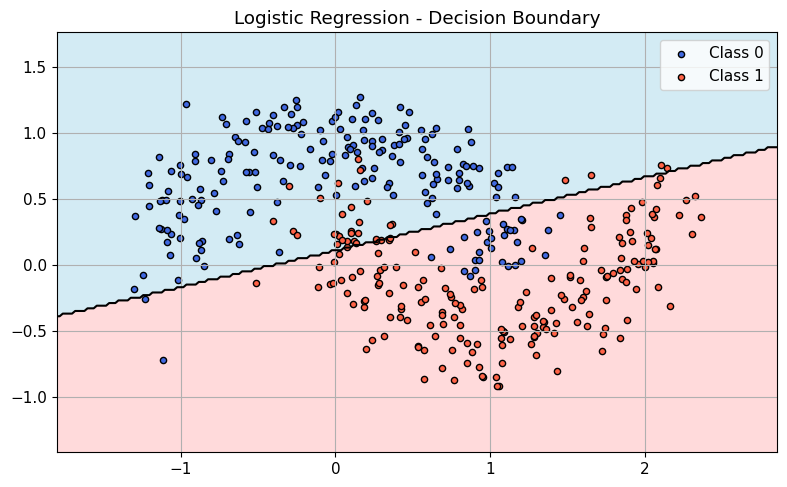

Logistic Regression Accuracy: 84.2%


In [ ]:
def plot_decision_boundary(predict_fn, X, Y, title="Decision Boundary"):
    """Plot the decision boundary of a binary classifier on 2D data."""
    margin = 0.5
    x_min, x_max = X[0].min() - margin, X[0].max() + margin
    y_min, y_max = X[1].min() - margin, X[1].max() + margin

    # Create a mesh grid
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Flatten mesh into (2, num_grid_points)
    grid = np.c_[xx.ravel(), yy.ravel()].T

    # Predict on grid
    Z = predict_fn(grid)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=["#a8d8ea", "#ffb6b9"], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X[0, Y[0] == 0], X[1, Y[0] == 0], c="royalblue", edgecolors="k", s=20, label="Class 0")
    ax.scatter(X[0, Y[0] == 1], X[1, Y[0] == 1], c="tomato", edgecolors="k", s=20, label="Class 1")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


predict_lr = lambda X_in: (sigmoid(w_lr.T @ X_in + b_lr) > 0.5).astype(float)
plot_decision_boundary(predict_lr, X, Y, "Logistic Regression - Decision Boundary")

accuracy_lr = np.mean(predict_lr(X) == Y) * 100
print(f"Logistic Regression Accuracy: {accuracy_lr:.1f}%")

---
# 3) Single Layer Percepton

A single-layer neural network introduces **nonlinear feature extraction**:
the hidden layer learns a transformed representation of the input
where the classes become (more) linearly separable.

---

## 3.1 Nonlinearity

- **The XOR problem** illustrates the fundamental limitation of linear classifiers.
- No single hyperplane separates the classes.
- A hidden layer with nonlinear activations
can learn an intermediate representation that *is* linearly separable.

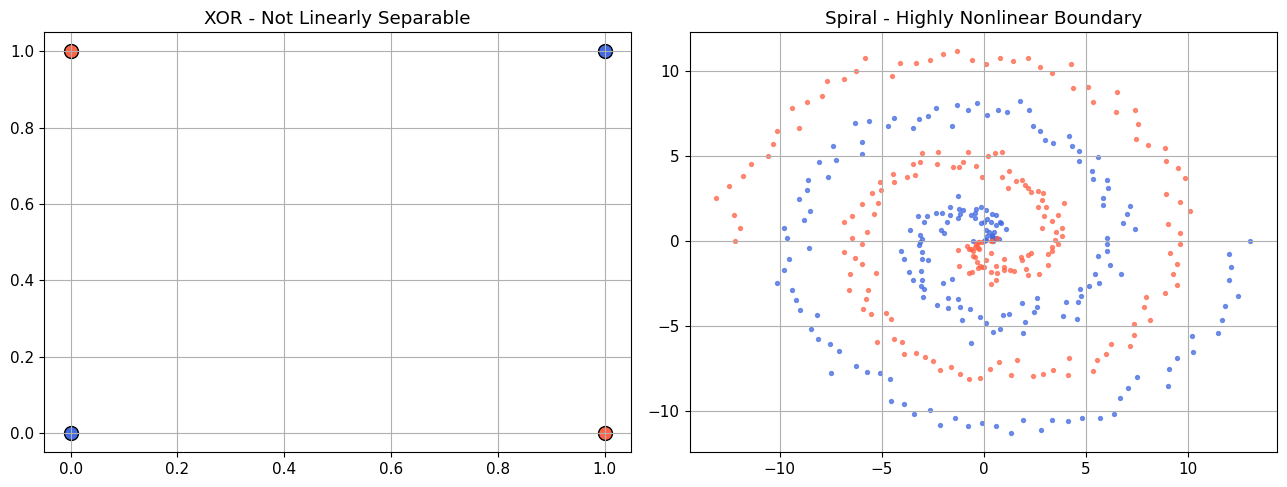

In [ ]:
# XOR dataset
X_xor = np.array([[0, 0, 1, 1], [0, 1, 0, 1]], dtype=float)
Y_xor = np.array([[0, 1, 1, 0]])

# Spiral dataset (2 classes, manually generated)
def make_spirals(num_samples_per_class=200, noise=0.5):
    """Generate two interleaving spirals."""
    n = num_samples_per_class
    theta = np.linspace(0, 4 * np.pi, n)

    r_a = theta + np.random.randn(n) * noise
    x_a = np.column_stack([r_a * np.cos(theta), r_a * np.sin(theta)])

    r_b = theta + np.random.randn(n) * noise
    x_b = np.column_stack([r_b * np.cos(theta + np.pi), r_b * np.sin(theta + np.pi)])

    # (2, 2*n)
    X = np.vstack([x_a, x_b]).T
    # (1, 2*n)
    Y = np.hstack([np.zeros(n), np.ones(n)]).reshape(1, -1)
    return X, Y


X_spiral, Y_spiral = make_spirals()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_xor[0, Y_xor[0] == 0], X_xor[1, Y_xor[0] == 0], c="royalblue", s=100, edgecolors="k")
axes[0].scatter(X_xor[0, Y_xor[0] == 1], X_xor[1, Y_xor[0] == 1], c="tomato", s=100, edgecolors="k")
axes[0].set_title("XOR - Not Linearly Separable")

axes[1].scatter(X_spiral[0, Y_spiral[0] == 0], X_spiral[1, Y_spiral[0] == 0], c="royalblue", s=8, alpha=0.7)
axes[1].scatter(X_spiral[0, Y_spiral[0] == 1], X_spiral[1, Y_spiral[0] == 1], c="tomato", s=8, alpha=0.7)
axes[1].set_title("Spiral - Highly Nonlinear Boundary")

plt.tight_layout()
plt.show()

## 3.2 Architecture

```
Input (2)  →  Hidden (hidden_dim, tanh)  →  Output (1, sigmoid)
```

**Parameters:**
- $W^{[1]} \in \mathbb{R}^{h \times n_x}$, $b^{[1]} \in \mathbb{R}^{h \times 1}$ — hidden layer
- $W^{[2]} \in \mathbb{R}^{1 \times h}$, $b^{[2]} \in \mathbb{R}^{1 \times 1}$ — output layer

**Why tanh over sigmoid for hidden layers?**
- tanh is zero-centered: outputs in $(-1, 1)$ rather than $(0, 1)$
- Zero-centered activations mean gradients for the next layer are not biased in one direction
- sigmoid is reserved for the output layer where we need a probability

In [ ]:
def initialize_shallow_nn(input_dim, hidden_dim, output_dim=1):
    """He initialization for a 1-hidden-layer network.

    He init: W ~ N(0, sqrt(2/fan_in)) designed for layers followed by ReLU,
    but works well for tanh with the factor adjusted.
    """
    params = {
        # (hidden_dim, input_dim)
        "W1": np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / input_dim),
        # (hidden_dim, 1)
        "b1": np.zeros((hidden_dim, 1)),
        # (output_dim, hidden_dim)
        "W2": np.random.randn(output_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim),
        # (output_dim, 1)
        "b2": np.zeros((output_dim, 1)),
    }
    return params


params = initialize_shallow_nn(input_dim=2, hidden_dim=4)
for k, v in params.items():
    print(f"{k}: {v.shape}")

W1: (4, 2)
b1: (4, 1)
W2: (1, 4)
b2: (1, 1)


## 3.3 Forward Pass

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$
$$A^{[1]} = \tanh(Z^{[1]})$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$
$$A^{[2]} = \sigma(Z^{[2]})$$

The cache stores all intermediate values needed for the backward pass.

In [ ]:
def shallow_forward(X, params):
    """Forward pass for a 1-hidden-layer network. Returns output and cache."""
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

    # (hidden_dim, input_dim) @ (input_dim, batch_num) + (hidden_dim, 1) → (hidden_dim, batch_num)
    Z1 = W1 @ X + b1
    # (hidden_dim, batch_num) → (hidden_dim, batch_num)
    A1 = np.tanh(Z1)

    # (output_dim, hidden_dim) @ (hidden_dim, batch_num) + (output_dim, 1) → (output_dim, batch_num)
    Z2 = W2 @ A1 + b2
    # (output_dim, batch_num) → (output_dim, batch_num)
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

## 3.4 Backward Pass

Starting from the cost $J$, we apply the chain rule layer by layer:

**Output layer** ($l=2$):
$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} (A^{[1]})^T$$
$$db^{[2]} = \frac{1}{m} \sum dZ^{[2]}$$

**Hidden layer** ($l=1$):
$$dA^{[1]} = (W^{[2]})^T dZ^{[2]}$$
$$dZ^{[1]} = dA^{[1]} \odot (1 - (A^{[1]})^2) \qquad \text{(tanh derivative)}$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} X^T$$
$$db^{[1]} = \frac{1}{m} \sum dZ^{[1]}$$

Note the **tanh derivative**: $\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z)$

In [ ]:
def shallow_backward(X, Y, params, cache):
    """Backward pass for a 1-hidden-layer network."""
    W1, W2 = params["W1"], params["W2"]
    A1, A2 = cache["A1"], cache["A2"]
    batch_num = X.shape[1]

    # Output layer gradients
    # (1, batch_num)
    dZ2 = A2 - Y
    # (1, batch_num) @ (batch_num, hidden_dim) → (1, hidden_dim)
    dW2 = (1 / batch_num) * (dZ2 @ A1.T)
    # (1, 1)
    db2 = (1 / batch_num) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden layer gradients
    # (hidden_dim, 1).T @ (1, batch_num) → (hidden_dim, batch_num)
    dA1 = W2.T @ dZ2
    # (hidden_dim, batch_num) — tanh derivative: 1 - tanh^2(z)
    dZ1 = dA1 * (1 - A1 ** 2)
    # (hidden_dim, input_dim)
    dW1 = (1 / batch_num) * (dZ1 @ X.T)
    # (hidden_dim, 1)
    db1 = (1 / batch_num) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

## 3.5 Training

In [ ]:
def train_shallow_nn(X, Y, hidden_dim=10, learning_rate=1.0,
                    num_iterations=5000, print_every=500):
    """Train a 1-hidden-layer neural network with gradient descent."""
    input_dim = X.shape[0]
    params = initialize_shallow_nn(input_dim, hidden_dim)
    costs = []

    for i in range(num_iterations):
        A2, cache = shallow_forward(X, params)
        cost = compute_cost(Y, A2)
        costs.append(cost)
        grads = shallow_backward(X, Y, params, cache)

        # Parameter updates
        params["W1"] -= learning_rate * grads["dW1"]
        params["b1"] -= learning_rate * grads["db1"]
        params["W2"] -= learning_rate * grads["dW2"]
        params["b2"] -= learning_rate * grads["db2"]

        if i % print_every == 0:
            accuracy = np.mean((A2 > 0.5).astype(float) == Y) * 100
            print(f"Iter {i:5d} | Cost: {cost:.4f} | Accuracy: {accuracy:.1f}%")

    return params, costs


params_nn, costs_nn = train_shallow_nn(X, Y, hidden_dim=10, learning_rate=1.0,
                                       num_iterations=5000)

Iter     0 | Cost: 0.6387 | Accuracy: 73.2%
Iter   500 | Cost: 0.0878 | Accuracy: 97.0%
Iter  1000 | Cost: 0.0762 | Accuracy: 96.8%
Iter  1500 | Cost: 0.0716 | Accuracy: 96.8%
Iter  2000 | Cost: 0.0689 | Accuracy: 96.8%
Iter  2500 | Cost: 0.0667 | Accuracy: 97.0%
Iter  3000 | Cost: 0.0646 | Accuracy: 97.0%
Iter  3500 | Cost: 0.0628 | Accuracy: 97.0%
Iter  4000 | Cost: 0.0612 | Accuracy: 97.5%
Iter  4500 | Cost: 0.0599 | Accuracy: 97.5%


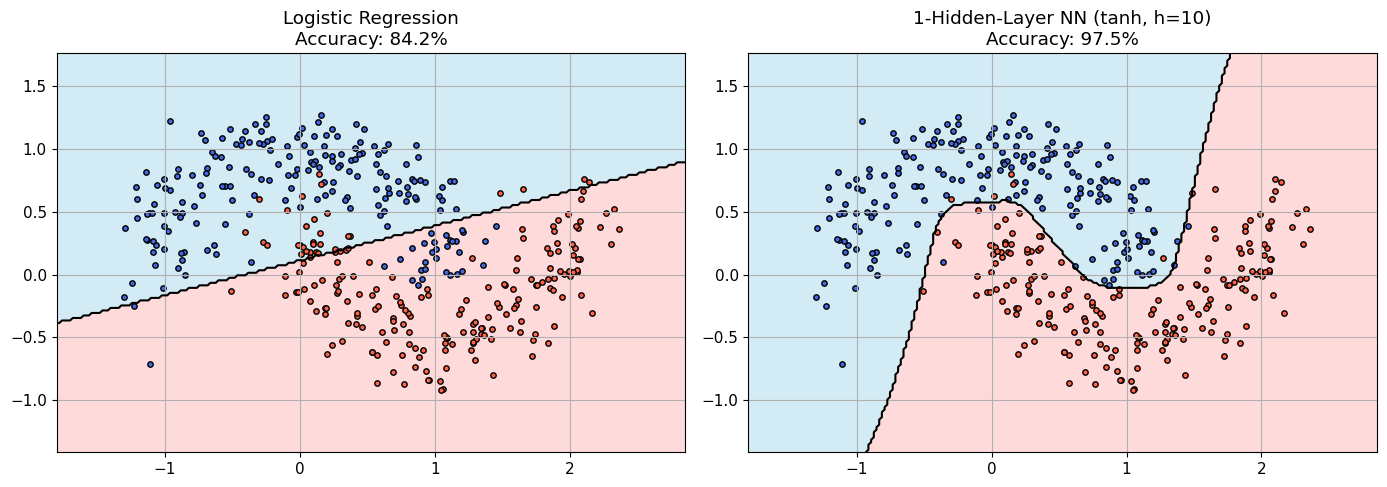

In [ ]:
# Side-by-side decision boundary comparison
predict_nn = lambda X_in: (shallow_forward(X_in, params_nn)[0] > 0.5).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred_fn, title in zip(
    axes,
    [predict_lr, predict_nn],
    ["Logistic Regression", "1-Hidden-Layer NN (tanh, h=10)"],
):
    margin = 0.5
    x_min, x_max = X[0].min() - margin, X[0].max() + margin
    y_min, y_max = X[1].min() - margin, X[1].max() + margin
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()].T
    Z = pred_fn(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=["#a8d8ea", "#ffb6b9"], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X[0, Y[0] == 0], X[1, Y[0] == 0], c="royalblue", edgecolors="k", s=15)
    ax.scatter(X[0, Y[0] == 1], X[1, Y[0] == 1], c="tomato", edgecolors="k", s=15)
    acc = np.mean(pred_fn(X) == Y) * 100
    ax.set_title(f"{title}\nAccuracy: {acc:.1f}%")

plt.tight_layout()
plt.show()

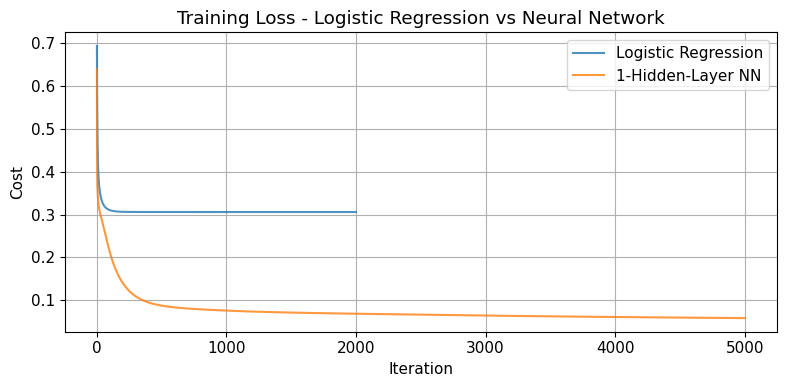

In [ ]:
# Compare training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs_lr, label="Logistic Regression", alpha=0.8)
ax.plot(costs_nn, label="1-Hidden-Layer NN", alpha=0.8)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost")
ax.set_title("Training Loss - Logistic Regression vs Neural Network")
ax.legend()
plt.tight_layout()
plt.show()

---
# 4) Deep Neural Networks

- Generalize from a fixed 2-layer network to an **arbitrary L-layer** architecture.
- The key insight: every layer performs the same `linear → activation` computation,
so we can implement the entire network with a loop over layers.

## 4.1 Parameter Initialization

**Why initialization matters:** If weights are too large, activations saturate and gradients
vanish. Too small, and the signal shrinks to zero through layers.

**He initialization** (for ReLU): $W^{[l]} \sim N\left(0, \sqrt{\frac{2}{n^{[l-1]}}}\right)$

This keeps the variance of activations roughly constant across layers, preventing
the exploding/vanishing gradient problem at initialization.

In [ ]:
def relu(Z):
    """ReLU activation."""
    # (*) → (*)
    return np.maximum(0, Z)


def relu_backward(dA, Z):
    """ReLU gradient: pass through where Z > 0, block where Z <= 0."""
    # (*) → (*)
    return dA * (Z > 0).astype(float)


def sigmoid_backward(dA, Z):
    """Sigmoid gradient: sigma(z) * (1 - sigma(z))."""
    # (*) → (*)
    s = sigmoid(Z)
    return dA * s * (1 - s)


def initialize_deep_nn(layer_dims):
    """He initialization for an L-layer network.

    layer_dims: list of layer sizes [n_x, n_1, ..., n_L]
    """
    params = {}
    num_layers = len(layer_dims) - 1

    for l in range(1, num_layers + 1):

        # (layer_dims[l], layer_dims[l-1])

        params[f"W{l}"] = np.random.randn(
            layer_dims[l], layer_dims[l - 1]
        ) * np.sqrt(2.0 / layer_dims[l - 1])

        # (layer_dims[l], 1)
        params[f"b{l}"] = np.zeros((layer_dims[l], 1))

    return params


# Verify initialization
test_dims = [2, 10, 5, 3, 1]
test_params = initialize_deep_nn(test_dims)
for k, v in test_params.items():
    print(f"{k}: shape={v.shape}, std={v.std():.4f}")

W1: shape=(10, 2), std=0.9548
b1: shape=(10, 1), std=0.0000
W2: shape=(5, 10), std=0.5093
b2: shape=(5, 1), std=0.0000
W3: shape=(3, 5), std=0.6204
b3: shape=(3, 1), std=0.0000
W4: shape=(1, 3), std=0.2587
b4: shape=(1, 1), std=0.0000


## 4.2 Forward Propagation

Each layer $l$ computes:
$$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = g^{[l]}(Z^{[l]})$$

where $g^{[l]}$ is ReLU for $l = 1, \ldots, L-1$ and sigmoid for $l = L$.

We **cache** $(A^{[l-1]}, Z^{[l]})$ at each layer — these are needed during backprop.

In [ ]:
def deep_forward(X, params):
    """Forward propagation through an L-layer network.

    Layers 1..L-1 use ReLU; layer L uses sigmoid.
    Returns final activation and list of caches.
    """
    num_layers = len(params) // 2
    caches = []
    A = X

    for l in range(1, num_layers):
        A_prev = A
        W, b = params[f"W{l}"], params[f"b{l}"]

        # Input: (layer_dims[l], layer_dims[l-1]) @ (layer_dims[l-1], batch_num) + (layer_dims[l], 1)
        # Output: (layer_dims[l], batch_num)
        Z = W @ A_prev + b

        # (layer_dims[l], batch_num) → (layer_dims[l], batch_num)
        A = relu(Z)

        caches.append({"A_prev": A_prev, "Z": Z, "W": W, "b": b})

    # Output layer: sigmoid
    W_L, b_L = params[f"W{num_layers}"], params[f"b{num_layers}"]
    # (output_dim, hidden_dim) @ (hidden_dim, batch_num) + (output_dim, 1)
    #   → (output_dim, batch_num)
    Z_L = W_L @ A + b_L
    # (output_dim, batch_num) → (output_dim, batch_num)
    A_L = sigmoid(Z_L)

    caches.append({"A_prev": A, "Z": Z_L, "W": W_L, "b": b_L})

    return A_L, caches

## 4.3 Backward Propagation

The backward pass computes gradients layer by layer, from output to input.

For each layer $l$, given $dA^{[l]}$ (the gradient flowing back):

$$dZ^{[l]} = dA^{[l]} \odot g'^{[l]}(Z^{[l]})$$
$$dW^{[l]} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^T$$
$$db^{[l]} = \frac{1}{m} \sum_{\text{axis=1}} dZ^{[l]}$$
$$dA^{[l-1]} = (W^{[l]})^T dZ^{[l]}$$

The output layer starts with:
$$dA^{[L]} = -\frac{Y}{A^{[L]}} + \frac{1-Y}{1-A^{[L]}}$$

Or equivalently (combining with sigmoid derivative):
$$dZ^{[L]} = A^{[L]} - Y$$

In [ ]:
def deep_backward(Y, A_L, caches):
    """Backward propagation through an L-layer network.

    Returns gradients for all parameters.
    """
    num_layers = len(caches)
    batch_num = Y.shape[1]
    grads = {}

    # Output layer: sigmoid + BCE combined gives dZ = A - Y
    cache_L = caches[num_layers - 1]
    # (output_dim, batch_num)
    dZ = A_L - Y
    # (output_dim, prev_dim)
    grads[f"dW{num_layers}"] = (1 / batch_num) * (dZ @ cache_L["A_prev"].T)
    # (output_dim, 1)
    grads[f"db{num_layers}"] = (1 / batch_num) * np.sum(dZ, axis=1, keepdims=True)
    # (prev_dim, batch_num)
    dA_prev = cache_L["W"].T @ dZ

    # Hidden layers: ReLU
    for l in reversed(range(1, num_layers)):
        cache_l = caches[l - 1]

        # (layer_dims[l], batch_num)
        dZ = relu_backward(dA_prev, cache_l["Z"])
        # (layer_dims[l], layer_dims[l-1])
        grads[f"dW{l}"] = (1 / batch_num) * (dZ @ cache_l["A_prev"].T)
        # (layer_dims[l], 1)
        grads[f"db{l}"] = (1 / batch_num) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            # (layer_dims[l-1], batch_num)
            dA_prev = cache_l["W"].T @ dZ

    return grads

## 4.4 Parameter Update

Simple gradient descent update for all layers:

$$W^{[l]} \leftarrow W^{[l]} - \alpha \cdot dW^{[l]}$$
$$b^{[l]} \leftarrow b^{[l]} - \alpha \cdot db^{[l]}$$

In [ ]:
def update_parameters(params, grads, learning_rate):
    """Apply gradient descent update to all parameters."""
    num_layers = len(params) // 2
    for l in range(1, num_layers + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params

## 4.5 Multi Layer Perceptron

In [ ]:
def train_deep_nn(X, Y, layer_dims, learning_rate=0.01,
                  num_iterations=10000, print_every=1000):
    """Train an L-layer deep neural network.

    layer_dims: [input_dim, h1, h2, ..., output_dim]
    """
    params = initialize_deep_nn(layer_dims)
    costs = []

    for i in range(num_iterations):
        A_L, caches = deep_forward(X, params)
        cost = compute_cost(Y, A_L)
        costs.append(cost)
        grads = deep_backward(Y, A_L, caches)
        params = update_parameters(params, grads, learning_rate)

        if i % print_every == 0:
            accuracy = np.mean((A_L > 0.5).astype(float) == Y) * 100
            print(f"Iter {i:5d} | Cost: {cost:.4f} | Accuracy: {accuracy:.1f}%")

    return params, costs

In [ ]:
# Train a 4-layer network on the moon dataset
layer_dims_deep = [2, 20, 10, 5, 1]
print(f"Architecture: {' -> '.join(map(str, layer_dims_deep))}")
print("=" * 50)

params_deep, costs_deep = train_deep_nn(
    X, Y,
    layer_dims=layer_dims_deep,
    learning_rate=0.05,
    num_iterations=10000,
    print_every=1000,
)

Architecture: 2 -> 20 -> 10 -> 5 -> 1
Iter     0 | Cost: 0.6005 | Accuracy: 50.0%
Iter  1000 | Cost: 0.0894 | Accuracy: 97.0%
Iter  2000 | Cost: 0.0565 | Accuracy: 98.2%
Iter  3000 | Cost: 0.0499 | Accuracy: 98.2%
Iter  4000 | Cost: 0.0466 | Accuracy: 98.2%
Iter  5000 | Cost: 0.0436 | Accuracy: 98.2%
Iter  6000 | Cost: 0.0416 | Accuracy: 98.2%
Iter  7000 | Cost: 0.0400 | Accuracy: 98.2%
Iter  8000 | Cost: 0.0385 | Accuracy: 98.2%
Iter  9000 | Cost: 0.0371 | Accuracy: 98.5%


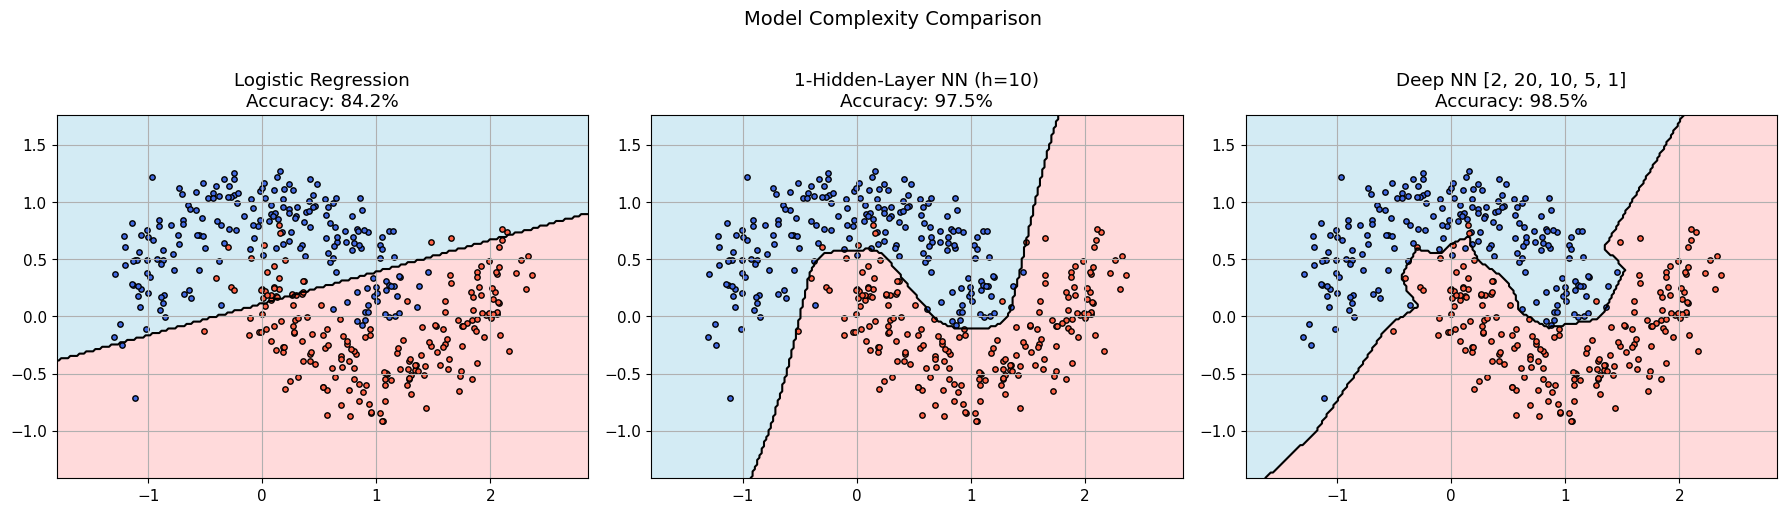

In [ ]:
# Decision boundary of the deep network
predict_deep = lambda X_in: (deep_forward(X_in, params_deep)[0] > 0.5).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred_fn, title in zip(
    axes,
    [predict_lr, predict_nn, predict_deep],
    [
        "Logistic Regression",
        "1-Hidden-Layer NN (h=10)",
        f"Deep NN {layer_dims_deep}",
    ],
):
    margin = 0.5
    x_min, x_max = X[0].min() - margin, X[0].max() + margin
    y_min, y_max = X[1].min() - margin, X[1].max() + margin
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()].T
    Z = pred_fn(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=["#a8d8ea", "#ffb6b9"], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X[0, Y[0] == 0], X[1, Y[0] == 0], c="royalblue", edgecolors="k", s=15)
    ax.scatter(X[0, Y[0] == 1], X[1, Y[0] == 1], c="tomato", edgecolors="k", s=15)
    acc = np.mean(pred_fn(X) == Y) * 100
    ax.set_title(f"{title}\nAccuracy: {acc:.1f}%")

plt.suptitle("Model Complexity Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

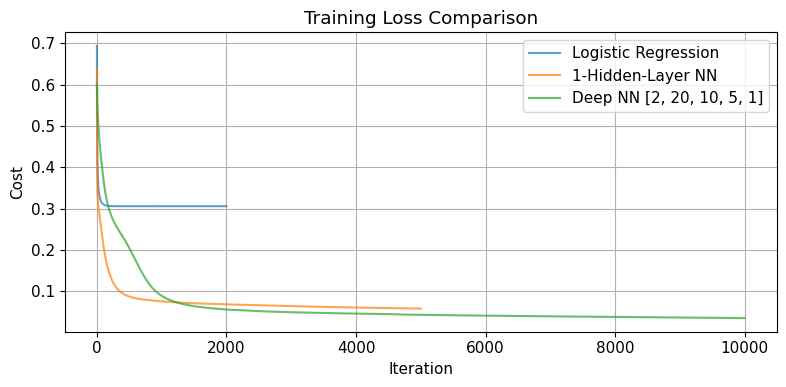

In [ ]:
# Training loss curves: all three models
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs_lr, label="Logistic Regression", alpha=0.7)
ax.plot(costs_nn, label="1-Hidden-Layer NN", alpha=0.7)
ax.plot(costs_deep, label=f"Deep NN {layer_dims_deep}", alpha=0.7)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost")
ax.set_title("Training Loss Comparison")
ax.legend()
plt.tight_layout()
plt.show()

Iter     0 | Cost: 1.7700 | Accuracy: 50.0%
Iter  5000 | Cost: 0.5987 | Accuracy: 65.5%
Iter 10000 | Cost: 0.6253 | Accuracy: 57.8%
Shallow (2->50->1): 59.8%
Iter     0 | Cost: 2.0272 | Accuracy: 49.2%
Iter  5000 | Cost: 0.1953 | Accuracy: 92.5%
Iter 10000 | Cost: 0.2459 | Accuracy: 89.2%
3-Layer (2->50->30->1): 71.0%
Iter     0 | Cost: 1.7694 | Accuracy: 50.2%
Iter  5000 | Cost: 0.0181 | Accuracy: 99.2%
Iter 10000 | Cost: 0.0106 | Accuracy: 99.5%
4-Layer (2->50->30->20->1): 99.8%


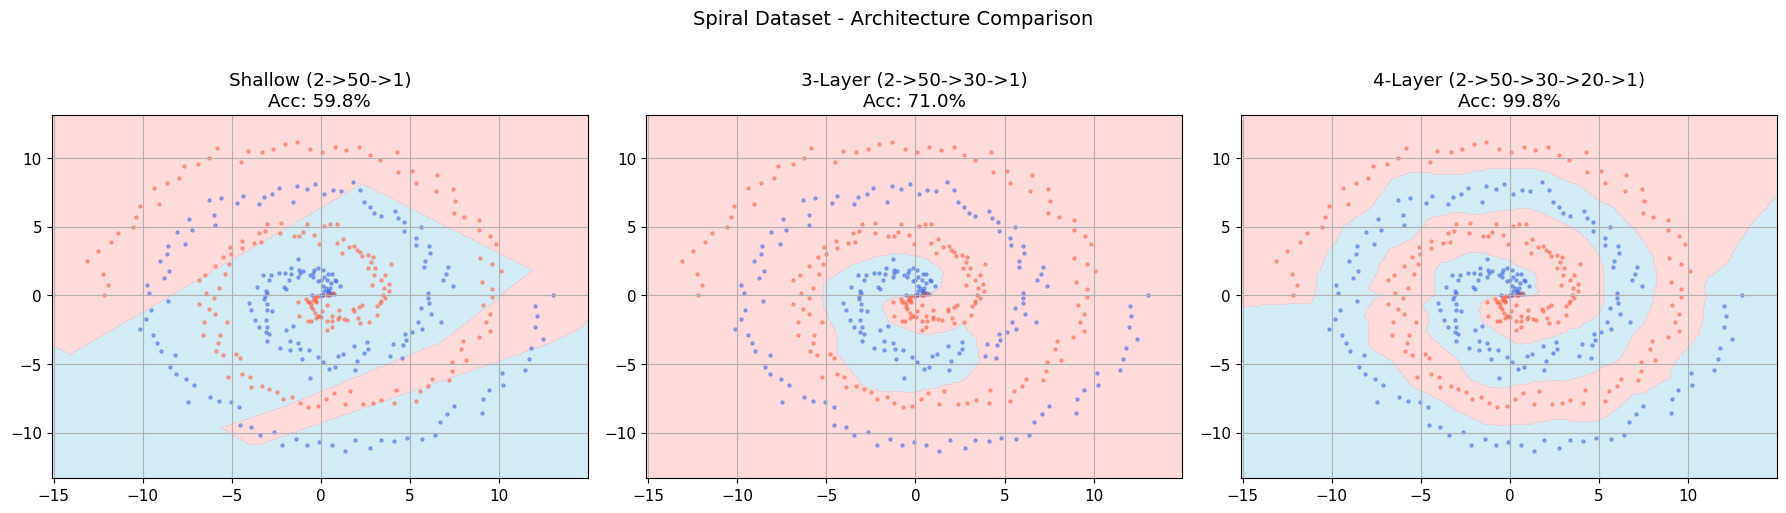

In [ ]:
# Train deeper networks on the spiral dataset
configs = [
    ([2, 50, 1], 1.0, 15000, "Shallow (2->50->1)"),
    ([2, 50, 30, 1], 0.5, 15000, "3-Layer (2->50->30->1)"),
    ([2, 50, 30, 20, 1], 0.1, 15000, "4-Layer (2->50->30->20->1)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (dims, lr, iters, name) in zip(axes, configs):
    params_s, costs_s = train_deep_nn(
        X_spiral, Y_spiral, dims, learning_rate=lr,
        num_iterations=iters, print_every=5000
    )
    pred_fn = lambda X_in, p=params_s: (deep_forward(X_in, p)[0] > 0.5).astype(float)

    margin = 2.0
    x_min, x_max = X_spiral[0].min() - margin, X_spiral[0].max() + margin
    y_min, y_max = X_spiral[1].min() - margin, X_spiral[1].max() + margin
    h_step = 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h_step), np.arange(y_min, y_max, h_step))
    grid = np.c_[xx.ravel(), yy.ravel()].T
    Z = pred_fn(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=["#a8d8ea", "#ffb6b9"], alpha=0.5)
    ax.scatter(
        X_spiral[0, Y_spiral[0] == 0], X_spiral[1, Y_spiral[0] == 0],
        c="royalblue", s=5, alpha=0.5,
    )
    ax.scatter(
        X_spiral[0, Y_spiral[0] == 1], X_spiral[1, Y_spiral[0] == 1],
        c="tomato", s=5, alpha=0.5,
    )
    acc = np.mean(pred_fn(X_spiral) == Y_spiral) * 100
    ax.set_title(f"{name}\nAcc: {acc:.1f}%")
    print(f"{name}: {acc:.1f}%")

plt.suptitle("Spiral Dataset - Architecture Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# 5) Computational Graphs & Backpropagation Deep Dive

## What is a Computational Graph?

A computational graph decomposes a complex function into primitive operations,
each represented as a **node**. Edges carry intermediate values.

**Example:** $f(x, y, z) = (x + y) \cdot z$

```
x ──→ [+] ──→ q ──→ [×] ──→ f
y ──↗                z ──↗
```

Where $q = x + y$, $f = q \cdot z$.

**Forward pass:** compute each node's value from inputs to output.
**Backward pass:** compute each node's gradient from output to inputs.

**Local gradients:**
- $\frac{\partial q}{\partial x} = 1$, $\frac{\partial q}{\partial y} = 1$
- $\frac{\partial f}{\partial q} = z$, $\frac{\partial f}{\partial z} = q$

**Chain rule** gives the global gradients:
- $\frac{\partial f}{\partial x} = \frac{\partial f}{\partial q} \cdot \frac{\partial q}{\partial x} = z$

In [ ]:
class Value:
    """A node in a computational graph that tracks value and gradient."""

    def __init__(self, data, label=""):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._backward = lambda: None
        self._children = set()

    def __add__(self, other):
        out = Value(self.data + other.data, label=f"({self.label}+{other.label})")
        out._children = {self, other}

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0

        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, label=f"({self.label}*{other.label})")
        out._children = {self, other}

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        out._backward = _backward
        return out

    def backward(self):
        """Topological sort + reverse-mode differentiation."""
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value({self.label}={self.data:.4f}, grad={self.grad:.4f})"


# Forward pass
x = Value(2.0, "x")
y = Value(-3.0, "y")
z = Value(4.0, "z")

q = x + y
f = q * z

# Backward pass
f.backward()

print(f"f = (x + y) * z = ({x.data} + {y.data}) * {z.data} = {f.data}")
print(f"df/dx = z = {x.grad}  (expected: {z.data})")
print(f"df/dy = z = {y.grad}  (expected: {z.data})")
print(f"df/dz = q = x + y = {z.grad}  (expected: {x.data + y.data})")

f = (x + y) * z = (2.0 + -3.0) * 4.0 = -4.0
df/dx = z = 4.0  (expected: 4.0)
df/dy = z = 4.0  (expected: 4.0)
df/dz = q = x + y = -1.0  (expected: -1.0)


## 5.1 Forward Mode vs Reverse Mode AD

**Forward mode** (tangent-linear): propagates derivatives *alongside* the forward computation.
Each forward pass computes the derivative w.r.t. **one input** variable.
Cost: $O(n)$ forward passes for $n$ inputs.

**Reverse mode** (adjoint): first does a full forward pass, then propagates derivatives
*backward* from a **single output**.
Cost: $O(m)$ backward passes for $m$ outputs.

**For neural networks:** We have millions of parameters (inputs to the loss function)
but only 1 scalar output (the loss). Reverse mode wins overwhelmingly — this is why
**backpropagation = reverse-mode AD**.

| | Forward Mode | Reverse Mode |
|---|---|---|
| Direction | Input → Output | Output → Input |
| Cost per sweep | derivatives w.r.t. 1 input | derivatives w.r.t. all inputs |
| Best when | few inputs, many outputs | many inputs, few outputs |
| Neural nets | Impractical | Backpropagation |

In [ ]:
def forward_mode_gradient(f, x, h=1e-7):
    """Forward mode: one pass per input dimension (finite differences analog)."""
    n = len(x)
    grad = np.zeros(n)
    for i in range(n):
        x_plus = x.copy()
        x_plus[i] += h
        grad[i] = (f(x_plus) - f(x)) / h
    return grad


def reverse_mode_gradient_quadratic(A, x):
    """Reverse mode for f(x) = x^T A x: one backward pass gets all gradients.

    Analytical gradient: (A + A^T)x
    """
    # (embed_dim,) → (embed_dim,)
    return (A + A.T) @ x


# Compare speed for f: R^n → R
embed_dim = 100
A_mat = np.random.randn(embed_dim, embed_dim)
x_test = np.random.randn(embed_dim)
f_quad = lambda x: x @ A_mat @ x

# Forward mode (n function evaluations)
start = time.perf_counter()
grad_fwd = forward_mode_gradient(f_quad, x_test)
time_fwd = time.perf_counter() - start

# Reverse mode (1 analytical backward pass)
start = time.perf_counter()
grad_rev = reverse_mode_gradient_quadratic(A_mat, x_test)
time_rev = time.perf_counter() - start

print(f"Forward mode time:  {time_fwd:.6f}s  ({embed_dim} function evaluations)")
print(f"Reverse mode time:  {time_rev:.6f}s  (1 backward pass)")
print(f"Speedup: {time_fwd / time_rev:.0f}x")
print(f"Max gradient difference: {np.max(np.abs(grad_fwd - grad_rev)):.2e}")

Forward mode time:  0.001954s  (100 function evaluations)
Reverse mode time:  0.000134s  (1 backward pass)
Speedup: 15x
Max gradient difference: 8.09e-07


## 5.2 Manual Backprop Derivation for a 3-Layer Network

Let us trace the complete gradient flow through a concrete 3-layer network:

```
X → [Z1=W1@X+b1] → [A1=relu(Z1)] → [Z2=W2@A1+b2] → [A2=relu(Z2)] → [Z3=W3@A2+b3] → [A3=sig(Z3)] → L
```

**Forward pass stores:** $Z^{[1]}, A^{[1]}, Z^{[2]}, A^{[2]}, Z^{[3]}, A^{[3]}$

**Backward pass computes (in this order):**

1. $dZ^{[3]} = A^{[3]} - Y$ (sigmoid + BCE shortcut)
2. $dW^{[3]} = \frac{1}{m} dZ^{[3]} A^{[2]T}$, $\quad db^{[3]} = \frac{1}{m} \mathbf{1}^T dZ^{[3]T}$
3. $dA^{[2]} = W^{[3]T} dZ^{[3]}$
4. $dZ^{[2]} = dA^{[2]} \odot \mathbb{1}[Z^{[2]} > 0]$ (ReLU derivative)
5. $dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$, $\quad db^{[2]} = \frac{1}{m} \mathbf{1}^T dZ^{[2]T}$
6. $dA^{[1]} = W^{[2]T} dZ^{[2]}$
7. $dZ^{[1]} = dA^{[1]} \odot \mathbb{1}[Z^{[1]} > 0]$
8. $dW^{[1]} = \frac{1}{m} dZ^{[1]} X^T$, $\quad db^{[1]} = \frac{1}{m} \mathbf{1}^T dZ^{[1]T}$

Let us implement this explicitly (without the generic loop) to see every step.

In [ ]:
# Explicit 3-layer backprop with every operation annotated

np.random.seed(7)
input_dim_ex, h1, h2, output_dim_ex = 2, 8, 6, 1
batch_num = X.shape[1]

# Initialize
W1 = np.random.randn(h1, input_dim_ex) * np.sqrt(2 / input_dim_ex)
b1 = np.zeros((h1, 1))
W2 = np.random.randn(h2, h1) * np.sqrt(2 / h1)
b2 = np.zeros((h2, 1))
W3 = np.random.randn(output_dim_ex, h2) * np.sqrt(2 / h2)
b3 = np.zeros((output_dim_ex, 1))

# === FORWARD PASS ===

# (h1, input_dim) @ (input_dim, batch_num) + (h1, 1) → (h1, batch_num)
Z1 = W1 @ X + b1
# (h1, batch_num) → (h1, batch_num)
A1 = relu(Z1)

# (h2, h1) @ (h1, batch_num) + (h2, 1) → (h2, batch_num)
Z2 = W2 @ A1 + b2
# (h2, batch_num) → (h2, batch_num)
A2 = relu(Z2)

# (output_dim, h2) @ (h2, batch_num) + (output_dim, 1) → (output_dim, batch_num)
Z3 = W3 @ A2 + b3
# (output_dim, batch_num) → (output_dim, batch_num)
A3 = sigmoid(Z3)

cost = compute_cost(Y, A3)
print(f"Initial cost: {cost:.4f}")

# === BACKWARD PASS ===

# Layer 3 (output): sigmoid + BCE shortcut
# (output_dim, batch_num)
dZ3 = A3 - Y
# (output_dim, h2)
dW3 = (1 / batch_num) * (dZ3 @ A2.T)
# (output_dim, 1)
db3_grad = (1 / batch_num) * np.sum(dZ3, axis=1, keepdims=True)

# Layer 2: ReLU
# (h2, batch_num)
dA2 = W3.T @ dZ3
# (h2, batch_num)
dZ2 = dA2 * (Z2 > 0).astype(float)
# (h2, h1)
dW2_grad = (1 / batch_num) * (dZ2 @ A1.T)
# (h2, 1)
db2_grad = (1 / batch_num) * np.sum(dZ2, axis=1, keepdims=True)

# Layer 1: ReLU
# (h1, batch_num)
dA1 = W2.T @ dZ2
# (h1, batch_num)
dZ1 = dA1 * (Z1 > 0).astype(float)
# (h1, input_dim)
dW1_grad = (1 / batch_num) * (dZ1 @ X.T)
# (h1, 1)
db1_grad = (1 / batch_num) * np.sum(dZ1, axis=1, keepdims=True)

print(f"\nGradient shapes:")
print(f"dW3: {dW3.shape}, db3: {db3_grad.shape}")
print(f"dW2: {dW2_grad.shape}, db2: {db2_grad.shape}")
print(f"dW1: {dW1_grad.shape}, db1: {db1_grad.shape}")

Initial cost: 0.7900

Gradient shapes:
dW3: (1, 6), db3: (1, 1)
dW2: (6, 8), db2: (6, 1)
dW1: (8, 2), db1: (8, 1)


## 5.3 Jacobians and the Chain Rule

For a vector-valued function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the **Jacobian** is:

$$J = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix} \in \mathbb{R}^{m \times n}$$

The chain rule for composed functions $\mathbf{h} = \mathbf{g} \circ \mathbf{f}$ is:

$$J_h = J_g \cdot J_f$$

In backpropagation, we never explicitly form the full Jacobian — instead, we compute
**vector-Jacobian products (VJPs)**: $\mathbf{v}^T J$, which is exactly what `backward()` computes.

**Key insight:** For a layer $\mathbf{a} = g(W\mathbf{x} + \mathbf{b})$:
- The Jacobian $\frac{\partial \mathbf{a}}{\partial \mathbf{x}} = \text{diag}(g'(z)) \cdot W$
- The VJP: $\frac{\partial L}{\partial \mathbf{x}} = \left(\frac{\partial L}{\partial \mathbf{a}}\right)^T \cdot \text{diag}(g'(z)) \cdot W$

In [ ]:
def compute_jacobian_numerical(f, x, h=1e-5):
    """Compute the full Jacobian matrix numerically via central differences."""
    n = x.shape[0]
    f0 = f(x)
    m = f0.shape[0]

    # (m, n)
    J = np.zeros((m, n))

    for i in range(n):
        x_plus = x.copy()
        x_plus[i] += h
        x_minus = x.copy()
        x_minus[i] -= h
        # Central difference for higher accuracy
        J[:, i] = (f(x_plus) - f(x_minus)) / (2 * h)

    return J


# Jacobian of a ReLU layer: a = relu(Wx + b)
hidden_dim_j = 4
input_dim_j = 3
W_j = np.random.randn(hidden_dim_j, input_dim_j)
b_j = np.random.randn(hidden_dim_j, 1)

layer_fn = lambda x: relu(W_j @ x.reshape(-1, 1) + b_j).ravel()
x_j = np.random.randn(input_dim_j)

J_num = compute_jacobian_numerical(layer_fn, x_j)

# Analytical Jacobian: diag(relu'(z)) @ W
z_j = W_j @ x_j.reshape(-1, 1) + b_j
relu_deriv = (z_j.ravel() > 0).astype(float)
J_analytical = np.diag(relu_deriv) @ W_j

print(f"Jacobian shape: {J_num.shape}  (output_dim x input_dim)")
print(f"\nNumerical Jacobian:\n{J_num.round(4)}")
print(f"\nAnalytical Jacobian:\n{J_analytical.round(4)}")
print(f"\nMax difference: {np.max(np.abs(J_num - J_analytical)):.2e}")

Jacobian shape: (4, 3)  (output_dim x input_dim)

Numerical Jacobian:
[[ 0.      0.      0.    ]
 [ 1.4382  1.5033 -0.2127]
 [ 0.332   0.735  -0.1929]
 [-1.778   0.6547  0.8944]]

Analytical Jacobian:
[[ 0.      0.      0.    ]
 [ 1.4382  1.5033 -0.2127]
 [ 0.332   0.735  -0.1929]
 [-1.778   0.6547  0.8944]]

Max difference: 9.75e-12


In [ ]:
# Chain rule: Jacobian of composed layers
# f: x → relu(W1 @ x + b1) → relu(W2 @ h + b2)

dim_0, dim_1, dim_2 = 3, 4, 2
W1_j = np.random.randn(dim_1, dim_0)
b1_j = np.random.randn(dim_1, 1)
W2_j = np.random.randn(dim_2, dim_1)
b2_j = np.random.randn(dim_2, 1)

# Full composed function
composed = lambda x: relu(W2_j @ relu(W1_j @ x.reshape(-1, 1) + b1_j) + b2_j).ravel()
x_c = np.random.randn(dim_0)

# Numerical Jacobian of the full composition
J_composed_num = compute_jacobian_numerical(composed, x_c)

# Analytical: J_composed = J_layer2 @ J_layer1
z1_c = W1_j @ x_c.reshape(-1, 1) + b1_j
a1_c = relu(z1_c)
z2_c = W2_j @ a1_c + b2_j

J_layer1 = np.diag((z1_c.ravel() > 0).astype(float)) @ W1_j
J_layer2 = np.diag((z2_c.ravel() > 0).astype(float)) @ W2_j

# Chain rule: J_total = J_2 @ J_1
J_composed_analytical = J_layer2 @ J_layer1

print(f"Composed Jacobian shape: {J_composed_num.shape}")
print(f"\nNumerical:\n{J_composed_num.round(4)}")
print(f"\nAnalytical (chain rule):\n{J_composed_analytical.round(4)}")
print(f"\nMax difference: {np.max(np.abs(J_composed_num - J_composed_analytical)):.2e}")

Composed Jacobian shape: (2, 3)

Numerical:
[[-0.9863 -1.2311 -2.8314]
 [ 0.      0.      0.    ]]

Analytical (chain rule):
[[-0.9863 -1.2311 -2.8314]
 [ 0.      0.      0.    ]]

Max difference: 2.89e-11


## 5.4 Gradient Checking (Numerical Verification)

Gradient checking verifies analytical gradients by comparing with **numerical gradients**:

$$\frac{\partial J}{\partial \theta_i} \approx \frac{J(\theta_i + \epsilon) - J(\theta_i - \epsilon)}{2\epsilon}$$

If the relative difference between analytical and numerical gradients is:
- $< 10^{-7}$: excellent
- $< 10^{-5}$: acceptable, likely a precision issue
- $> 10^{-3}$: **bug in your backward pass**

We implement this for our L-layer network to verify its correctness.

In [ ]:
def gradient_check(X, Y, layer_dims, epsilon=1e-7):
    """Compare analytical gradients (backprop) with numerical gradients.

    Returns the relative difference: should be < 1e-7 for correct implementation.
    """
    params = initialize_deep_nn(layer_dims)

    # Analytical gradients via backprop
    A_L, caches = deep_forward(X, params)
    grads = deep_backward(Y, A_L, caches)

    # Flatten all parameters and gradients into vectors
    param_keys = sorted(params.keys())
    theta = np.concatenate([params[k].ravel() for k in param_keys])
    d_theta = np.concatenate([grads[f"d{k}"].ravel() for k in param_keys])

    num_params = theta.shape[0]
    d_theta_numerical = np.zeros(num_params)

    def unflatten(vec):
        """Reconstruct parameter dict from flat vector."""
        p = {}
        idx = 0
        for k in param_keys:
            shape = params[k].shape
            size = params[k].size
            p[k] = vec[idx : idx + size].reshape(shape)
            idx += size
        return p

    # Compute numerical gradient for each parameter
    for i in range(num_params):
        theta_plus = theta.copy()
        theta_plus[i] += epsilon
        theta_minus = theta.copy()
        theta_minus[i] -= epsilon

        # (output_dim, batch_num)
        A_plus, _ = deep_forward(X, unflatten(theta_plus))
        A_minus, _ = deep_forward(X, unflatten(theta_minus))

        cost_plus = compute_cost(Y, A_plus)
        cost_minus = compute_cost(Y, A_minus)

        d_theta_numerical[i] = (cost_plus - cost_minus) / (2 * epsilon)

    # Relative difference
    numerator = np.linalg.norm(d_theta - d_theta_numerical)
    denominator = np.linalg.norm(d_theta) + np.linalg.norm(d_theta_numerical)
    relative_diff = numerator / (denominator + 1e-30)

    return relative_diff, d_theta, d_theta_numerical


# Run gradient check on a small network (small for speed)
np.random.seed(1)
X_small = np.random.randn(2, 5)
Y_small = (np.random.randn(1, 5) > 0).astype(float)

diff, grad_analytical, grad_numerical = gradient_check(X_small, Y_small, [2, 4, 3, 1])

print(f"Relative difference: {diff:.2e}")
if diff < 1e-7:
    print("Gradient check PASSED: backprop implementation is correct")
elif diff < 1e-5:
    print("Gradient check MARGINAL: likely numerical precision issue")
else:
    print("Gradient check FAILED: bug in backward pass")

Relative difference: 1.95e-09
Gradient check PASSED: backprop implementation is correct


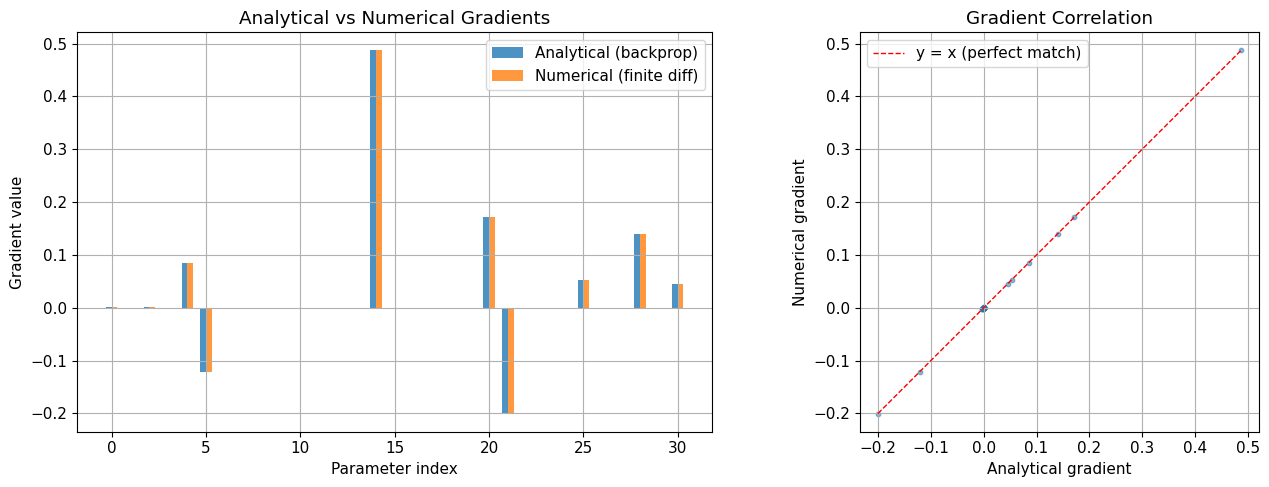

In [ ]:
# Visualize analytical vs numerical gradients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_to_plot = min(50, len(grad_analytical))
indices = np.arange(num_to_plot)

axes[0].bar(indices - 0.15, grad_analytical[:num_to_plot], 0.3,
            label="Analytical (backprop)", alpha=0.8)
axes[0].bar(indices + 0.15, grad_numerical[:num_to_plot], 0.3,
            label="Numerical (finite diff)", alpha=0.8)
axes[0].set_xlabel("Parameter index")
axes[0].set_ylabel("Gradient value")
axes[0].set_title("Analytical vs Numerical Gradients")
axes[0].legend()

# Scatter: perfect match gives points on y=x line
axes[1].scatter(grad_analytical, grad_numerical, alpha=0.5, s=10)
lims = [
    min(grad_analytical.min(), grad_numerical.min()),
    max(grad_analytical.max(), grad_numerical.max()),
]
axes[1].plot(lims, lims, "r--", linewidth=1, label="y = x (perfect match)")
axes[1].set_xlabel("Analytical gradient")
axes[1].set_ylabel("Numerical gradient")
axes[1].set_title("Gradient Correlation")
axes[1].legend()
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

---
# Summary

In this notebook we built the complete forward-backward machinery of deep learning from scratch:

| Component | Key Equation | Section |
|---|---|---|
| Sigmoid | $\sigma(z) = 1/(1+e^{-z})$ | 1.3, 2.2 |
| BCE Loss | $-\frac{1}{m}\sum[y\log\hat{y}+(1-y)\log(1-\hat{y})]$ | 2.3 |
| Gradient Descent | $\theta \leftarrow \theta - \alpha \nabla_\theta J$ | 2.5 |
| ReLU | $\max(0, z)$, derivative $\mathbb{1}[z>0]$ | 4.2 |
| He Init | $W \sim \mathcal{N}(0, \sqrt{2/n_{\text{in}}})$ | 4.2 |
| Backprop | $dZ^{[l]} = dA^{[l]} \odot g'(Z^{[l]})$ | 4.5 |
| Gradient Check | $\frac{\|d\theta - d\theta_{\text{num}}\|}{\|d\theta\| + \|d\theta_{\text{num}}\|} < 10^{-7}$ | 5.5 |

**Key takeaways:**
1. **Vectorization** is essential: NumPy operations are 100-1000x faster than Python loops
2. **Nonlinearity** is what makes neural networks powerful: without it, L layers collapse to 1
3. **Backpropagation** is just the chain rule applied systematically on a computational graph
4. **Reverse-mode AD** is optimal when there are many inputs and few outputs (= neural nets)
5. **Always gradient-check** your implementation: it catches bugs that are invisible otherwise

**Next notebook:** Optimization algorithms (momentum, Adam), regularization (L2, dropout), and batch normalization.